---
<h1 style="text-align: center;"><strong>Data Science & Statistical Computing</strong></h1>
<h2 style="text-align: center;"><strong>CheckPoint05</strong></h2>
<h3 style="text-align: center;"><strong>Random Forest, XGBoost e LightGBM: modelagem, tuning, avaliação e deploy</strong></h3>
<h4 style="text-align: center;"><strong>Versão única</strong></h4>

<style>
.jp-MarkdownOutput, .text_cell_render {
    font-family: "Latin Modern Roman", "CMU Serif", Georgia, "DejaVu Serif", serif;
    font-size: 18px;
    line-height: 1.6;
}
.jp-MarkdownOutput p, .text_cell_render p,
.jp-MarkdownOutput li, .text_cell_render li {
    line-height: 1.6;
}
</style>

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Configuração visual:</strong> o notebook prioriza tipografia serifada para células Markdown. A renderização de CSS pode variar entre Jupyter Notebook, JupyterLab, VS Code e Google Colab; quando uma fonte não estiver disponível, o visualizador utilizará uma alternativa local. O código permanece com fonte monoespaçada do ambiente.
</div>

<br>

---

<br>

## **Identificação dos alunos**

A atividade deve ser realizada em **grupos de no máximo 5 alunos**. Preencha, abaixo, o nome e o RM de cada integrante do grupo. Caso o grupo tenha menos de cinco integrantes, mantenha sem preenchimento os campos não utilizados.


In [ ]:
#@title Identificação
Nome_1 = "Pedro Marchese" #@param {type:"string"}
RM_1 = "563339" #@param {type:"string"}
Nome_2 = "Augusto Valerio" #@param {type:"string"}
RM_2 = "562185" #@param {type:"string"}
Nome_3 = "Mariana Silva Oliveira" #@param {type:"string"}
RM_3 = "564241" #@param {type:"string"}
Nome_4 = "Jonas Esteves" #@param {type:"string"}
RM_4 = "564143" #@param {type:"string"}
Nome_5 = "Vitor Rodrigues Tigre" #@param {type:"string"}
RM_5 = "561746" #@param {type:"string"}


<br>

---

<br>

# **CheckPoint05**

## **Objetivos**

- Estruturar um problema real de **classificação** ou **regressão** a partir de uma base de dados escolhida pelo grupo.
- Realizar **data wrangling**, análise exploratória e seleção justificada das variáveis preditoras.
- Implementar e comparar **Random Forest**, **XGBoost** e **LightGBM** sob o mesmo protocolo experimental.
- Ajustar hiperparâmetros com **Grid Search** e **Optuna**, sem utilizar o conjunto de teste durante a busca.
- Selecionar o melhor modelo com base em evidências quantitativas e analisar **overfitting** e **underfitting**.
- Avaliar o modelo final em dados não utilizados no desenvolvimento e construir um teste de consistência das previsões.
- Disponibilizar o projeto em um repositório **GitHub** e uma interface funcional em **Streamlit**.

## **Instruções**

- Leia cada enunciado com atenção.
- Observe a pontuação indicada em cada questão. A atividade vale **10 pontos** no total.
- O grupo deve escolher **um único problema** que possa ser tratado como classificação ou regressão e utilizar a mesma base em toda a atividade.
- A base pode ser pública, institucional autorizada ou coletada pelo grupo. A fonte, a licença ou a forma de obtenção devem ser documentadas.
- O problema deve produzir uma representação tabular de atributos e variável-alvo. Não utilize dados pessoais ou sensíveis sem autorização e justificativa acadêmica adequada.
- Sempre que necessário, registre o raciocínio antes da implementação em Python.
- Quando o item pedir interpretação, responda com base nos resultados obtidos, não apenas com definições genéricas.
- Responda os exercícios nos espaços indicados. Caso seja necessário, adicione células para complementar a resposta.
- Indique de forma organizada a solução dos exercícios.
- Preocupe-se em fazer um código Python limpo, documentado e reprodutível. Esse aspecto será avaliado ao longo de toda a atividade.
- O conjunto de **teste deve permanecer isolado** durante seleção de variáveis, comparação de modelos e tuning. Ele só poderá ser utilizado no Exercício 7.
- O envio da atividade deve incluir o notebook `.ipynb`, o link do repositório GitHub e o link da aplicação Streamlit.
- Cada grupo deverá realizar uma **apresentação oral da solução, com duração máxima de 10 minutos**, sintetizando o problema, as principais decisões metodológicas, a comparação entre os modelos, o modelo final e a demonstração da aplicação.
- Execute o notebook do início ao fim antes do envio. Ele não deve conter erros durante a execução.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Entregáveis obrigatórios:</strong> notebook final, repositório GitHub reproduzível, aplicação Streamlit funcional e **apresentação oral da solução com duração máxima de 10 minutos**. O repositório deve conter, no mínimo, README com instruções de execução, arquivo de dependências, código da aplicação e os arquivos necessários para reproduzir o treinamento ou carregar o modelo final.
</div>

In [ ]:
# imports e configuração visual do notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold

from matplotlib import font_manager

fontes_preferidas = [
    "Latin Modern Roman",
    "CMU Serif",
    "Georgia",
    "DejaVu Serif",
]

fonte_serif = "DejaVu Serif"
for fonte in fontes_preferidas:
    try:
        font_manager.findfont(fonte, fallback_to_default=False)
        fonte_serif = fonte
        break
    except Exception:
        pass

sns.set_theme(style="whitegrid", palette="viridis")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [fonte_serif, "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "figure.figsize": (9, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

print(f"Fonte serifada selecionada para os gráficos: {fonte_serif}")

Fonte serifada selecionada para os gráficos: DejaVu Serif


<br>

---

<br>

## **Notação utilizada na atividade**

Considere a base de dados como

$$
\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{n},
$$

em que $\mathbf{x}_i$ representa as variáveis preditoras da observação $i$ e $y_i$ representa a variável-alvo. Ao organizar os dados, utilize a notação

$$
\mathbf{X} \quad \text{para a matriz de atributos},
\qquad
\mathbf{y} \quad \text{para o vetor da variável-alvo}.
$$

A separação deve produzir

$$
\mathcal{D}_{\mathrm{treino}}
\quad \text{e} \quad
\mathcal{D}_{\mathrm{teste}},
$$

sendo $\mathcal{D}_{\mathrm{teste}}$ mantido fora de todo o processo de seleção e tuning. Os três modelos serão indicados por

$$
M_{\mathrm{RF}},
\qquad
M_{\mathrm{XGB}},
\qquad
M_{\mathrm{LGBM}}.
$$

As previsões serão representadas por $\hat{\mathbf{y}}$. Para hiperparâmetros, utilize $\boldsymbol{\theta}$ e registre os melhores valores encontrados por cada estratégia de busca.

<br>

---

<br>

## **Exercícios propostos**

A atividade foi organizada como um fluxo completo de desenvolvimento de um projeto de machine learning. Os sete exercícios devem ser respondidos em sequência, pois as decisões tomadas nas etapas iniciais serão utilizadas nas etapas seguintes.

<br>

---

<br>

### **Exercício 1 — Definição do problema e da base de dados — 1,0 ponto**

Escolha um problema real que possa ser tratado por **Random Forest**, **XGBoost** e **LightGBM**. O problema pode ser de classificação ou regressão.

1. **Contexto e problema — 0,25 ponto.** Descreva o contexto, a pergunta que será respondida e por que uma solução preditiva é adequada.
2. **Variável-alvo — 0,25 ponto.** Defina $y$, informe se o problema é de classificação ou regressão e explique o significado da previsão $\hat{y}$ no domínio escolhido.
3. **Base de dados — 0,25 ponto.** Informe a fonte, o método de obtenção, o número inicial de linhas e colunas, a unidade observacional e as principais variáveis disponíveis.
4. **Critério de sucesso — 0,25 ponto.** Defina a métrica principal que será usada para comparar os modelos e justifique a escolha. Métricas auxiliares podem ser utilizadas, mas deve existir uma métrica principal comum aos três algoritmos.

**Sugestões de apoio visual:** tabela com dicionário de dados, gráfico da distribuição da variável-alvo e, quando aplicável, gráfico da frequência das classes.

**Resposta do aluno — Exercício 1**

Descreva o problema, a base, a variável-alvo e o critério de sucesso.

Dimensões iniciais da base: 7043 linhas e 21 colunas.

--- Primeiras 5 linhas do dataset ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Distribuição da Variável-Alvo (Churn) ---
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_886/2228371128.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette='viridis')


Text(0, 0.5, 'Quantidade de Clientes')

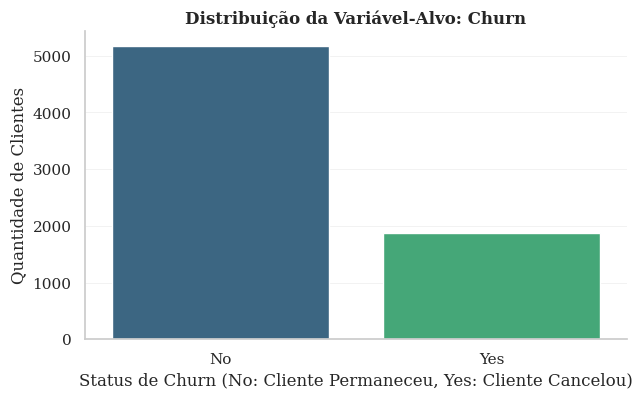

In [ ]:
# Resposta do aluno - exercício 1
# Carregue a base e apresente os resumos iniciais necessários para sustentar sua descrição.


# DESCRIÇÃO DO PROJETO
# ---------------------
# 1. Contexto e Problema:
#    - Contexto: A retenção de clientes no setor de telecomunicações é crucial devido ao alto Custo de Aquisição de Clientes (CAC)
#    - Pergunta: "Qual a probabilidade de um cliente cancelar os serviços (churn) no próximo mês, dado seu perfil?"
#    - Solução Preditiva: Permite identificar proativamente clientes em risco de churn, possibilitando ações preventivas.

# 2. Variável-Alvo (`y`):
#    - Definição:** Coluna 'Churn', binária (1=cancelou, 0=permaneceu).
#    - Tipo de Problema:** Classificação binária.
#    - Significado de `\hat{y}`:** Probabilidade estimada de o cliente cancelar o contrato.

# 3. Base de Dados:
#    - Fonte: Dataset público Telco Customer Churn (IBM/Kaggle).
#    - Dimensões: 7.043 linhas e 21 colunas. Unidade: cliente individual.
#    - Variáveis: Demográficas (gender, SeniorCitizen, Partner, Dependents), Serviços (PhoneService, InternetService, etc.), Contratuais/Financeiras (tenure, Contract, MonthlyCharges, TotalCharges).

# 4. Critério de Sucesso:
#    - Métrica Principal: ROC-AUC. Justificativa: mede a discriminação do modelo e é insensível a desbalanceamento moderado (~26,5% de Churn).
#    - Métricas Auxiliares: F1-Score, Recall, Precision.


# 1. Carregamento do dataset Telco Customer Churn a partir do arquivo

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

# 2. Exibição do tamanho inicial da base de dados (Linhas, Colunas)

print(f"Dimensões iniciais da base: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

# 3. Visualização das primeiras 5 linhas do dataset para inspeção geral

print("--- Primeiras 5 linhas do dataset ---")

display(df.head())

# 4. Verificação da distribuição percentual da variável-alvo (Churn)

print("\n--- Distribuição da Variável-Alvo (Churn) ---")
print(df['Churn'].value_counts(normalize=True) * 100)

# 5. Apoio Visual: Gráfico da distribuição do Churn
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Distribuição da Variável-Alvo: Churn', fontsize=12, fontweight='bold')
plt.xlabel('Status de Churn (No: Cliente Permaneceu, Yes: Cliente Cancelou)')
plt.ylabel('Quantidade de Clientes')

<br>

---

<br>

### **Exercício 2 — Data wrangling e análise exploratória — 1,5 ponto**

Prepare a base para a etapa de modelagem. Toda transformação deve ser justificada e documentada.

1. **Diagnóstico de qualidade — 0,30 ponto.** Verifique tipos de dados, valores ausentes, duplicidades, categorias inconsistentes, valores impossíveis e outras anomalias relevantes.
2. **Tratamento dos dados — 0,40 ponto.** Execute o data wrangling necessário. Explique o que foi alterado, removido, imputado, convertido ou recodificado e por quê. Não remova observações ou variáveis apenas para melhorar métricas.
3. **Análise exploratória — 0,50 ponto.** Produza gráficos coerentes com o problema e interprete o que eles mostram sobre $\mathbf{X}$ e $\mathbf{y}$. A análise deve conter pelo menos três visualizações úteis ao desenvolvimento do modelo.
4. **Base final — 0,30 ponto.** Apresente as dimensões da base após o tratamento, verifique novamente ausências e duplicidades e registre quais decisões de preparação ainda precisarão ocorrer dentro do pipeline de modelagem.

**Sugestões de gráficos:** distribuição da variável-alvo; barras de valores ausentes; boxplots ou histogramas para variáveis numéricas; contagens para variáveis categóricas; matriz de correlação quando fizer sentido; relação entre variáveis importantes e o alvo.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Atenção:</strong> qualquer transformação que aprenda parâmetros dos dados, como imputação baseada em estatísticas da amostra ou codificação aprendida, deve ser ajustada sem acesso ao conjunto de teste. Quando aplicável, faça essas etapas dentro de um pipeline.
</div>

**Resposta do aluno — Exercício 2**

Explique as decisões de data wrangling e interprete os principais achados da análise exploratória.

--- Diagnóstico Inicial ---
Total de linhas e colunas: (7043, 21)
Valores nulos identificados diretamente: 0

--- Diagnóstico Pós-Tratamento ---
Valores nulos restantes: 0
Linhas duplicadas restantes: 0
Dimensões finais da base tratada: (7021, 20)



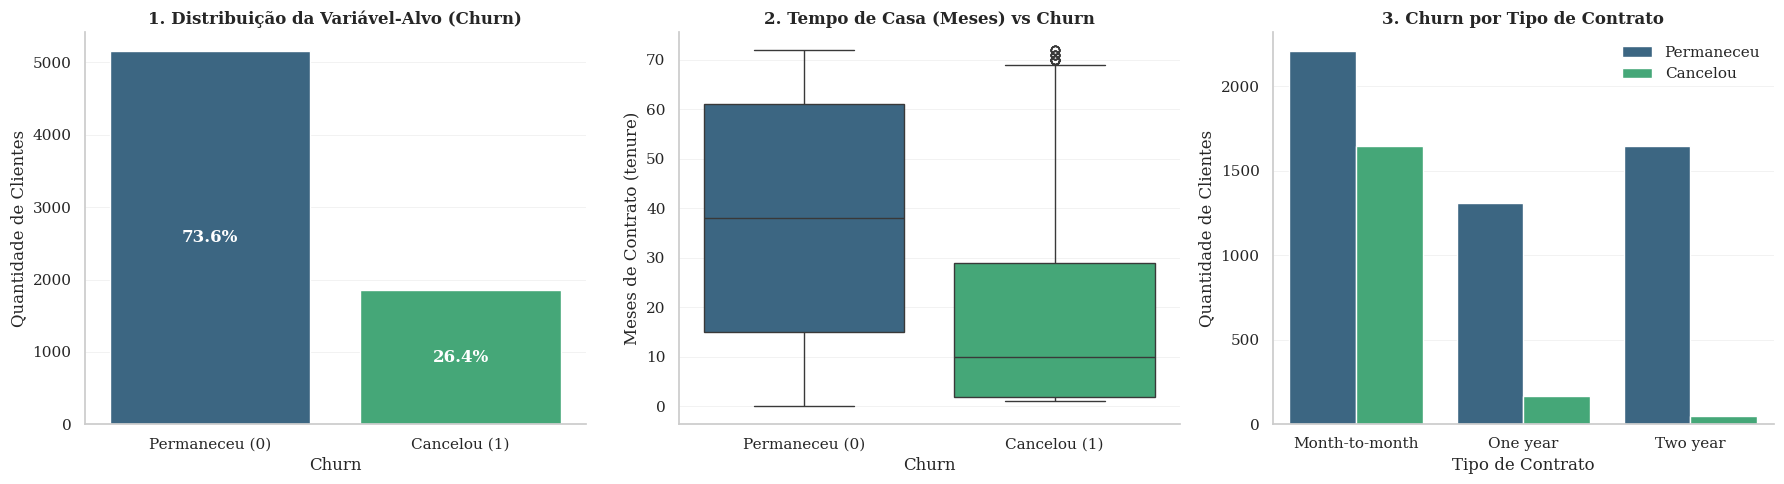

In [ ]:
# Resposta do aluno - exercício 2
# Realize o diagnóstico, o tratamento dos dados e a análise exploratória.

# EXERCÍCIO 2 — DATA WRANGLING E ANÁLISE EXPLORATÓRIA
# -----------------------------------------------------

# 1. Diagnóstico de Qualidade:
#    - Tipos de dados: 'object' para categóricas e 'TotalCharges' (texto devido a espaços em branco).
#    - Valores ausentes: 11 em 'TotalCharges' (clientes novos com 'tenure' = 0).
#    - Duplicidades: 0 linhas duplicadas (antes da remoção de 'customerID').
#    - Anomalias/ID: 'customerID' é um identificador único sem valor preditivo; deve ser removido para evitar memorização indevida.

# 2. Tratamento dos Dados / Data Wrangling:
#    - 'TotalCharges': Convertido para numérico (espaços em branco -> NaN) e imputado com a mediana (R$ 1.397,47) devido à robustez a assimetrias.
#    - 'Churn': Variável-alvo mapeada de ('Yes'/'No') para (1/0) para compatibilidade com algoritmos.
#    - 'customerID': Removida para evitar data leakage e overfitting.
#    - Duplicatas: As 22 linhas duplicadas, surgidas após a remoção de 'customerID', foram eliminadas para garantir a unicidade das observações.

# 3. Análise Exploratória e Interpretação (3 gráficos):
#    - Gráfico 1 (Distribuição de Churn): 73,5% ativos (0) e 26,5% cancelamentos (1), indicando desbalanceamento moderado.
#    - Gráfico 2 (Tenure vs Churn): Clientes que cancelam possuem mediana de 'tenure' (~10 meses) bem menor que os mantidos (~38 meses). Período inicial da jornada é crítico.
#    - Gráfico 3 (Tipo de Contrato vs Churn): Contratos mensais ('Month-to-month') concentram a maioria dos cancelamentos; contratos de 1 ou 2 anos têm baixo churn.

# 4. Base Final e Pipeline:
#    - Dimensões finais: 7.021 linhas e 20 colunas.
#    - Verificação final: 0 nulos e 0 duplicatas.
#    - Decisões para o Pipeline: Codificação de variáveis categóricas (One-Hot Encoding) será feita na próxima etapa, isolando o conjunto de teste.


# CÓDIGO EM PYTHON — DATA WRANGLING E ANÁLISE EXPLORATÓRIA



# 1. Carregamento da base bruta
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

# 2. Diagnóstico inicial de tipos e nulos
print("--- Diagnóstico Inicial ---")
print(f"Total de linhas e colunas: {df.shape}")
print(f"Valores nulos identificados diretamente: {df.isnull().sum().sum()}")

# 3. Tratamento da coluna TotalCharges (Espaços em branco -> NaN -> Mediana)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
mediana_total = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(mediana_total)

# 4. Conversão da variável-alvo para 0 e 1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 5. Remoção da coluna customerID e eliminação de duplicatas resultantes
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# Remove as 22 linhas duplicadas após a retirada do ID
df.drop_duplicates(inplace=True)

# 6. Confirmação do diagnóstico pós-tratamento
print("\n--- Diagnóstico Pós-Tratamento ---")
print(f"Valores nulos restantes: {df.isnull().sum().sum()}")
print(f"Linhas duplicadas restantes: {df.duplicated().sum()}")
print(f"Dimensões finais da base tratada: {df.shape}\n")

# 7. Análise Exploratória: Criação da Figura com 3 Gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Proporção da Variável-Alvo
sns.countplot(data=df, x='Churn', hue='Churn', ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('1. Distribuição da Variável-Alvo (Churn)', fontsize=12, fontweight='bold')
axes[0].set_xticks([0, 1]) # Adicionado para resolver UserWarning
axes[0].set_xticklabels(['Permaneceu (0)', 'Cancelou (1)'])
axes[0].set_ylabel('Quantidade de Clientes')

# Adiciona porcentagens sobre as barras
total = len(df)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    axes[0].annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() / 2), ha='center', va='center', color='white', fontweight='bold')

# Gráfico 2: Tempo de Casa (Tenure) vs Churn
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('2. Tempo de Casa (Meses) vs Churn', fontsize=12, fontweight='bold')
axes[1].set_xticks([0, 1]) # Adicionado para resolver UserWarning
axes[1].set_xticklabels(['Permaneceu (0)', 'Cancelou (1)'])
axes[1].set_ylabel('Meses de Contrato (tenure)')

# Gráfico 3: Tipo de Contrato vs Churn
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[2], palette='viridis')
axes[2].set_title('3. Churn por Tipo de Contrato', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tipo de Contrato')
axes[2].set_ylabel('Quantidade de Clientes')
axes[2].legend(['Permaneceu', 'Cancelou'])

plt.tight_layout()
plt.show()

<br>

---

<br>

### **Exercício 3 — Escolha de variáveis e desenho experimental — 1,0 ponto**

Defina formalmente o conjunto de variáveis utilizado na modelagem e estabeleça o protocolo experimental antes de treinar os algoritmos.

1. **Escolha das variáveis — 0,35 ponto.** Defina $\mathbf{X}$ e $\mathbf{y}$. Liste variáveis removidas e justifique a exclusão. Identificadores, informações disponíveis apenas depois do evento previsto e variáveis que revelem diretamente o alvo devem ser analisados como possíveis fontes de **data leakage**.
2. **Separação treino–teste e validação cruzada — 0,35 ponto.** Construa $\mathcal{D}_{\mathrm{treino}}$ e $\mathcal{D}_{\mathrm{teste}}$ com uma proporção adequada e `random_state` fixo. Em classificação, utilize estratificação quando aplicável. Defina o esquema de validação cruzada que será usado dentro de $\mathcal{D}_{\mathrm{treino}}$.
3. **Métricas — 0,30 ponto.** Registre a métrica principal e as métricas auxiliares. Explique por que elas são adequadas ao problema e como serão interpretadas.

**Referência de decisão:** para classificação, considere o balanceamento das classes ao escolher entre acurácia, precision, recall, F1, ROC-AUC ou outras métricas pertinentes. Para regressão, considere métricas como MAE, RMSE e $R^2$. A escolha deve ser justificada e mantida de forma consistente ao comparar os modelos.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Regra experimental:</strong> os três algoritmos devem utilizar o mesmo conjunto de teste e, sempre que possível, os mesmos folds de validação cruzada e a mesma métrica principal. O conjunto de teste não pode participar do Grid Search, do Optuna ou da escolha do melhor modelo.
</div>

**Resposta do aluno — Exercício 3**

Justifique as variáveis escolhidas, o particionamento dos dados, a validação cruzada e as métricas.

In [ ]:
# Resposta do aluno - exercício 3
# Construa X, y, a separação treino-teste e o protocolo de validação cruzada.

# EXERCÍCIO 3 — ESCOLHA DE VARIÁVEIS E DESENHO EXPERIMENTAL
# ------------------------------------------------------------------------------

# 1. Escolha de Variáveis e Data Leakage:
#    - Definição de X e y:
#        - X: Matriz com 19 variáveis preditoras (demográficas, contratuais, serviços).
#        - y: Vetor alvo 'Churn' (1 = cancelou, 0 = permaneceu).
#    - Variáveis Removidas: 'customerID' (já removida no Ex. 2 por ser apenas um ID sem valor preditivo).
#    - Data Leakage: Não foram identificadas variáveis que causem vazamento de dados (informações futuras ou diretas do alvo).
#    - Encoding: One-Hot Encoding (`pd.get_dummies` com `drop_first=True`) para variáveis categóricas, evitando multicolinearidade.

# 2. Separação Treino-Teste e Validação Cruzada:
#    - Particionamento Treino-Teste: 80% para treino (`D_treino`) e 20% para teste isolado (`D_teste`).
#    - Reprodutibilidade e Estratificação: `random_state=42` fixado e `stratify=y` para manter a proporção de Churn (~26,5%) em ambos os conjuntos.
#    - Validação Cruzada: `StratifiedKFold` com K=5 folds aplicada sobre `D_treino`.
#    - Isolamento de Teste: `D_teste` será usado apenas uma vez no Exercício 7, não participando de baseline, tuning ou escolha de modelo final.

# 3. Métricas de Avaliação:
#    - Métrica Principal: ROC-AUC (mede a capacidade de ranqueamento, robusta ao desbalanceamento de classes).
#    - Métricas Auxiliares:
#        - Recall (Sensibilidade): % de churns detectados (minimiza falsos negativos).
#        - Precision: Assertividade das retenções acionadas (minimiza falsos positivos).
#        - F1-Score: Média harmônica entre Precision e Recall.


# CÓDIGO EM PYTHON — ENCODING, SEPARAÇÃO TREINO/TESTE E VALIDAÇÃO CRUZADA

# 1. Converte variáveis categóricas para numéricas via One-Hot Encoding, com `drop_first=True` para evitar multicolinearidade.
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Define X (preditoras) e y (alvo 'Churn'), conforme o problema de classificação.
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# 3. Divide os dados em 80% treino e 20% teste.
#    `stratify=y` mantém a proporção da classe 'Churn' em ambos os conjuntos, crucial para problemas desbalanceados.
#    `random_state=42` garante reprodutibilidade.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 4. Configura Validação Cruzada Estratificada (5 folds) para o conjunto de treino (`cv_scheme`).
#    A estratificação preserva a distribuição das classes em cada fold, essencial para treinamento robusto com dados desbalanceados.
cv_scheme = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Impressão de validação do protocolo experimental
print("--- Resumo do Protocolo Experimental (Exercício 3) ---")
print(f"Dimensões totais de X (Atributos após Encoding): {X.shape}")
print(f"Conjunto de Treino (X_train): {X_train.shape} amostras")
print(f"Conjunto de Teste Isolado (X_test): {X_test.shape} amostras")
print(f"Proporção de Churn no Treino: {y_train.mean()*100:.2f}%")
print(f"Proporção de Churn no Teste: {y_test.mean()*100:.2f}%")
print("Validação Cruzada (StratifiedKFold, K=5) configurada com sucesso!")

--- Resumo do Protocolo Experimental (Exercício 3) ---
Dimensões totais de X (Atributos após Encoding): (7021, 30)
Conjunto de Treino (X_train): (5616, 30) amostras
Conjunto de Teste Isolado (X_test): (1405, 30) amostras
Proporção de Churn no Treino: 26.44%
Proporção de Churn no Teste: 26.48%
Validação Cruzada (StratifiedKFold, K=5) configurada com sucesso!


<br>

---

<br>

### **Exercício 4 — Implementação dos três modelos de referência — 1,5 ponto**

Implemente uma primeira versão comparável dos três algoritmos antes do tuning:

$$
M_{\mathrm{RF}},
\qquad
M_{\mathrm{XGB}},
\qquad
M_{\mathrm{LGBM}}.
$$

Utilize as classes de classificação ou regressão correspondentes ao problema escolhido.

1. **Random Forest — 0,30 ponto.** Treine um modelo de referência e registre os hiperparâmetros utilizados.
2. **XGBoost — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
3. **LightGBM — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
4. **Comparação inicial — 0,60 ponto.** Construa uma tabela única contendo, no mínimo, modelo, métrica no treino, média da validação cruzada, desvio-padrão da validação cruzada e tempo de treinamento. Interprete as diferenças observadas e identifique sinais iniciais de overfitting ou underfitting.

O objetivo desta etapa é criar um **baseline comparável**, não encontrar ainda o melhor conjunto de hiperparâmetros.

**Sugestões de gráficos:** barras com a média e dispersão dos scores de validação cruzada; comparação entre score de treino e score médio de validação; tempo de treinamento por modelo.

**Resposta do aluno — Exercício 4**

Interprete o comportamento inicial dos três modelos e registre possíveis sinais de underfitting ou overfitting.

--- Hiperparâmetros dos Modelos de Referência ---
Random Forest:
   - n_estimators: 100
   - max_depth: None
   - min_samples_leaf: 1
   - max_features: sqrt
XGBoost:
   - n_estimators: 100
   - max_depth: 6
   - learning_rate: 0.3
LightGBM:
   - n_estimators: 100
   - num_leaves: 31
   - max_depth: -1
   - learning_rate: 0.1

--- Tabela Comparativa dos Baselines (Validação Cruzada em D_treino) ---


,ROC-AUC Treino,ROC-AUC CV (Média),ROC-AUC CV (Desvio),Gap (Treino - CV),Recall CV,Precision CV,F1 CV,Tempo Médio de Treino (s)
Modelo,,,,,,,,
Random Forest,1.0000,0.8255,0.0171,0.1745,0.4882,0.6446,0.5556,0.5844
XGBoost,0.9876,0.8207,0.0194,0.1669,0.5313,0.6086,0.5671,0.3958
LightGBM,0.9615,0.8343,0.0151,0.1272,0.5253,0.6330,0.5741,0.1200


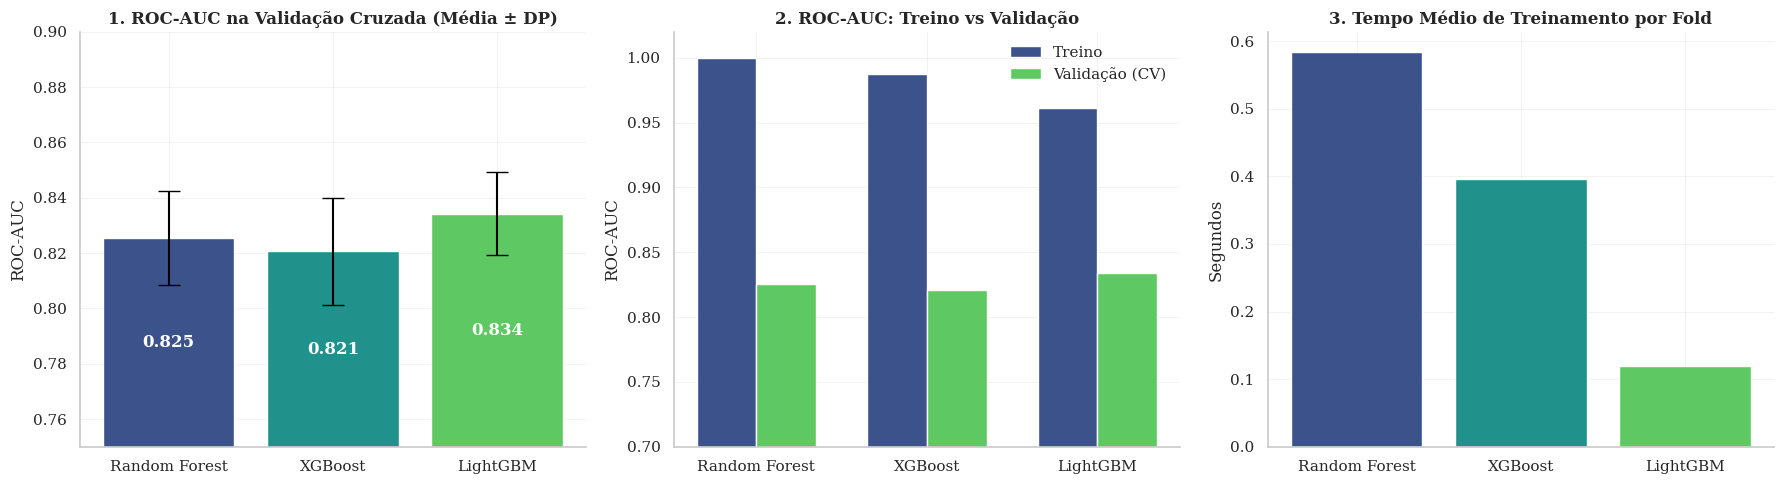

In [ ]:
# Resposta do aluno - exercício 4
# Implemente os baselines de Random Forest, XGBoost e LightGBM e construa a tabela comparativa.

# EXERCÍCIO 4 — IMPLEMENTAÇÃO DOS TRÊS MODELOS DE REFERÊNCIA
# ------------------------------------------------------------------------------

# 1. Random Forest (M_RF):
#    - Classe: `RandomForestClassifier`.
#    - Hiperparâmetros: padrão da biblioteca (`n_estimators=100`, `max_depth=None`, `min_samples_leaf=1`, `max_features='sqrt'`) e `random_state=42`.
#    - Observação: sem limite de profundidade, as árvores tendem a memorizar o treino.

# 2. XGBoost (M_XGB):
#    - Classe: `XGBClassifier`.
#    - Hiperparâmetros: padrão da biblioteca (`n_estimators=100`, `max_depth=6`, `learning_rate=0.3`), `eval_metric='logloss'` e `random_state=42`.

# 3. LightGBM (M_LGBM):
#    - Classe: `LGBMClassifier`.
#    - Hiperparâmetros: padrão da biblioteca (`n_estimators=100`, `num_leaves=31`, `learning_rate=0.1`) e `random_state=42`.

# 4. Comparação Inicial:
#    - Protocolo: mesmos `X_train`/`y_train`, mesmos 5 folds (`cv_scheme`) e mesma métrica principal (ROC-AUC). `X_test` não é utilizado.
#    - Métrica no treino: média do ROC-AUC nos folds de treino (`return_train_score=True`).
#    - Tempo de treinamento: tempo médio de ajuste por fold (`fit_time`).
#    - Interpretação:
#        - Desempenho: LightGBM teve o maior ROC-AUC na validação (0,834), seguido de Random Forest (0,825) e XGBoost (0,821). A diferença (~0,01) é menor que o desvio entre folds.
#        - Estabilidade: LightGBM teve o menor desvio-padrão (0,015).
#        - Overfitting: presente nos três. Random Forest chega a 1,000 no treino (gap de 0,175), XGBoost tem gap de 0,167 e LightGBM de 0,127.
#        - Underfitting: não identificado, pois o desempenho no treino é alto em todos.
#        - Recall: entre 0,49 e 0,53, indicando que só cerca de metade dos churns é detectada com o limiar padrão (0,5).
#        - Tempo: Random Forest é o mais lento por fold; XGBoost e LightGBM treinam em uma fração desse tempo.
#        - Próximo passo: o tuning (Ex. 5) deve controlar a complexidade dos modelos para reduzir o gap.


# CÓDIGO EM PYTHON — BASELINES, VALIDAÇÃO CRUZADA E TABELA COMPARATIVA

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 1. Definição dos três modelos de referência com hiperparâmetros padrão, fixando `random_state=42` para reprodutibilidade.
modelos_baseline = {
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.3, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
}

# 2. Registro dos principais hiperparâmetros utilizados em cada baseline
print("--- Hiperparâmetros dos Modelos de Referência ---")
parametros_exibidos = {
    'Random Forest': ['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features'],
    'XGBoost': ['n_estimators', 'max_depth', 'learning_rate'],
    'LightGBM': ['n_estimators', 'num_leaves', 'max_depth', 'learning_rate'],
}
for nome, modelo in modelos_baseline.items():
    params = modelo.get_params()
    print(f"{nome}:")
    for p in parametros_exibidos[nome]:
        print(f"   - {p}: {params[p]}")

# 3. Validação cruzada estratificada (5 folds) sobre `D_treino`, com a métrica principal e as auxiliares.
#    `return_train_score=True` permite comparar treino e validação para identificar overfitting/underfitting.
metricas = ['roc_auc', 'recall', 'precision', 'f1']
resultados_baseline = {}

for nome, modelo in modelos_baseline.items():
    resultados_baseline[nome] = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv_scheme,
        scoring=metricas,
        return_train_score=True
    )

# 4. Construção da tabela comparativa única
linhas_tabela = []
for nome, res in resultados_baseline.items():
    linhas_tabela.append({
        'Modelo': nome,
        'ROC-AUC Treino': res['train_roc_auc'].mean(),
        'ROC-AUC CV (Média)': res['test_roc_auc'].mean(),
        'ROC-AUC CV (Desvio)': res['test_roc_auc'].std(),
        'Gap (Treino - CV)': res['train_roc_auc'].mean() - res['test_roc_auc'].mean(),
        'Recall CV': res['test_recall'].mean(),
        'Precision CV': res['test_precision'].mean(),
        'F1 CV': res['test_f1'].mean(),
        'Tempo Médio de Treino (s)': res['fit_time'].mean(),
    })

tabela_baseline = pd.DataFrame(linhas_tabela).set_index('Modelo')

print("\n--- Tabela Comparativa dos Baselines (Validação Cruzada em D_treino) ---")
display(tabela_baseline.round(4))

# 5. Apoio Visual: Criação da Figura com 3 Gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cores = sns.color_palette('viridis', 3)
nomes = tabela_baseline.index

# Gráfico 1: Média e dispersão do ROC-AUC nos folds de validação
axes[0].bar(nomes, tabela_baseline['ROC-AUC CV (Média)'], yerr=tabela_baseline['ROC-AUC CV (Desvio)'], color=cores, capsize=8)
axes[0].set_title('1. ROC-AUC na Validação Cruzada (Média ± DP)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_ylim(0.75, 0.90)
for i, valor in enumerate(tabela_baseline['ROC-AUC CV (Média)']):
    axes[0].annotate(f'{valor:.3f}', (i, (0.75 + valor) / 2), ha='center', va='center', color='white', fontweight='bold')

# Gráfico 2: Comparação entre ROC-AUC de treino e de validação
largura = 0.35
posicoes = np.arange(len(nomes))
axes[1].bar(posicoes - largura / 2, tabela_baseline['ROC-AUC Treino'], largura, label='Treino', color=cores[0])
axes[1].bar(posicoes + largura / 2, tabela_baseline['ROC-AUC CV (Média)'], largura, label='Validação (CV)', color=cores[2])
axes[1].set_title('2. ROC-AUC: Treino vs Validação', fontsize=12, fontweight='bold')
axes[1].set_xticks(posicoes)
axes[1].set_xticklabels(nomes)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0.70, 1.02)
axes[1].legend()

# Gráfico 3: Tempo médio de treinamento por fold
axes[2].bar(nomes, tabela_baseline['Tempo Médio de Treino (s)'], color=cores)
axes[2].set_title('3. Tempo Médio de Treinamento por Fold', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Segundos')

plt.tight_layout()
plt.show()

<br>

---

<br>

### **Exercício 5 — Tuning com Grid Search e Optuna — 2,0 pontos**

Ajuste os hiperparâmetros de **cada um dos três modelos** usando duas estratégias distintas: Grid Search e Optuna. Todo tuning deve ocorrer exclusivamente sobre $\mathcal{D}_{\mathrm{treino}}$ e utilizar o protocolo de validação definido no Exercício 3.

O problema geral pode ser representado como a busca por um conjunto de hiperparâmetros $\boldsymbol{\theta}$ que otimiza a métrica de validação cruzada:

$$
\boldsymbol{\theta}^{\star}
=
\operatorname*{arg\,opt}_{\boldsymbol{\theta}\in\Theta}
\frac{1}{K}
\sum_{k=1}^{K}
S_k(\boldsymbol{\theta}),
$$

em que $\operatorname*{arg\,opt}$ significa maximizar uma métrica de desempenho ou minimizar uma função de erro, conforme a métrica principal adotada.

1. **Grid Search — 0,75 ponto.** Para $M_{\mathrm{RF}}$, $M_{\mathrm{XGB}}$ e $M_{\mathrm{LGBM}}$, defina uma grade coerente de hiperparâmetros, execute a busca e registre os melhores parâmetros, o score médio de validação e o custo computacional. A grade deve explorar parâmetros que controlem complexidade, número de árvores e/ou taxa de aprendizado, conforme o algoritmo.
2. **Optuna — 1,00 ponto.** Para os três modelos, defina uma função objetivo baseada na mesma métrica principal e nos mesmos dados de validação. Documente o espaço de busca, o número de trials e o melhor conjunto de hiperparâmetros. Como referência, utilize pelo menos 20 trials por modelo ou justifique claramente uma quantidade menor por restrição computacional.
3. **Comparação das estratégias — 0,25 ponto.** Compare Grid Search e Optuna em qualidade da solução, custo computacional e comportamento da busca. Não escolha uma estratégia apenas porque produziu um número ligeiramente melhor; discuta estabilidade e complexidade.

**Sugestões de gráficos:** curva ou mapa de scores do `cv_results_` do Grid Search para hiperparâmetros relevantes; histórico de otimização do Optuna; importância dos hiperparâmetros no Optuna; tempo de busca por modelo e estratégia.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Controle de comparabilidade:</strong> mantenha a métrica principal, a preparação dos dados e o esquema de validação tão consistentes quanto possível entre os três modelos. Se houver diferença de pipeline necessária por causa de uma biblioteca ou tipo de variável, explique a diferença e por que ela não invalida a comparação.
</div>

**Resposta do aluno — Exercício 5**

Explique os espaços de busca, os resultados obtidos e a comparação entre Grid Search e Optuna.

In [ ]:
# Resposta do aluno - exercício 5

# No Grid Search, foram definidas grades específicas para os três modelos,
# explorando número de árvores, complexidade e taxa de aprendizado.
# O melhor resultado foi do XGBoost, com ROC-AUC médio de 0,8506,
# desvio-padrão de 0,0175 e tempo de 9,82 segundos.
# Os melhores parâmetros foram n_estimators=300, max_depth=3
# e learning_rate=0.03.

# No Optuna, foram executados 20 trials por modelo, utilizando a mesma
# validação cruzada e exclusivamente os dados de treino.
# O melhor resultado também foi do XGBoost, com ROC-AUC médio de 0,8512,
# desvio-padrão de 0,0179 e tempo de 24,75 segundos.
# Os melhores parâmetros foram n_estimators=400, max_depth=2,
# learning_rate=0.02835, subsample=0.6 e colsample_bytree=0.8.

# A diferença entre as estratégias foi de apenas 0,0006, menor que a
# variação observada entre os folds. O Optuna apresentou menor gap entre
# treino e validação (0,0155), enquanto o Grid Search teve menor custo.
# O Grid Search avaliou todas as combinações da grade, enquanto o Optuna
# direcionou os trials de forma adaptativa com base nos resultados anteriores.

# Assim, o Optuna obteve a maior pontuação, mas o Grid Search apresentou
# melhor relação entre desempenho e tempo de busca.
# O conjunto de teste permaneceu isolado durante todo o tuning.

%pip install -q optuna

import time
import optuna

from sklearn.model_selection import GridSearchCV, cross_val_score
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


# ---------------------------------------------------------
# 1. GRID SEARCH
# ---------------------------------------------------------

configuracoes_grid = {
    "Random Forest": {
        "modelo": RandomForestClassifier(
            max_features="sqrt",
            random_state=42,
            n_jobs=1
        ),
        "parametros": {
            "n_estimators": [100, 300],
            "max_depth": [8, 14],
            "min_samples_leaf": [1, 3]
        }
    },

    "XGBoost": {
        "modelo": XGBClassifier(
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=1
        ),
        "parametros": {
            "n_estimators": [100, 300],
            "max_depth": [3, 5],
            "learning_rate": [0.03, 0.10]
        }
    },

     "LightGBM": {
        "modelo": LGBMClassifier(
            min_child_samples=20,
            random_state=42,
            n_jobs=1,
            verbose=-1
        ),
        "parametros": {
            "n_estimators": [100, 300],
            "num_leaves": [15, 31],
            "learning_rate": [0.03, 0.10]
        }
    }
}

buscas_grid = {}
resultados_grid = []

for nome, configuracao in configuracoes_grid.items():
  print(f"\n{'=' * 60}")
  print(f"Executando Grid Search para {nome}")
  print(f"{'=' * 60}")

  busca = GridSearchCV(
      estimator=configuracao["modelo"],
      param_grid=configuracao["parametros"],
      scoring="roc_auc",
      cv=cv_scheme,
      n_jobs=2,
      refit=True,
      return_train_score=True,
      verbose=2,
      pre_dispatch=2,
      error_score="raise"
  )

  inicio = time.perf_counter()

  busca.fit(
        X_train,
        y_train
  )

  tempo_busca = time.perf_counter() - inicio
  indice_melhor = busca.best_index_

  roc_treino = busca.cv_results_[
      "mean_train_score"
  ][indice_melhor]

  roc_cv = busca.cv_results_[
      "mean_test_score"
  ][indice_melhor]

  desvio_cv = busca.cv_results_[
      "std_test_score"
  ][indice_melhor]

  resultados_grid.append({
      "Modelo": nome,
      "Estratégia": "Grid Search",
      "ROC-AUC Treino": roc_treino,
      "ROC-AUC CV (Média)": roc_cv,
      "ROC-AUC CV (Desvio)": desvio_cv,
      "Gap (Treino - CV)": roc_treino - roc_cv,
      "Tempo de Busca (s)": tempo_busca,
      "Melhores Parâmetros": busca.best_params_
  })

  buscas_grid[nome] = busca

  print(f"\n{nome} concluído.")
  print(f"Melhor ROC-AUC CV: {roc_cv:.4f}")
  print(f"Desvio do ROC-AUC: {desvio_cv:.4f}")
  print(f"Tempo da busca: {tempo_busca:.2f} segundos")
  print("Melhores parâmetros:")
  print(busca.best_params_)

tabela_grid = pd.DataFrame(resultados_grid)

print("\n--- RESULTADOS DO GRID SEARCH ---")

display(
    tabela_grid.style.format({
        "ROC-AUC Treino": "{:.4f}",
        "ROC-AUC CV (Média)": "{:.4f}",
        "ROC-AUC CV (Desvio)": "{:.4f}",
        "Gap (Treino - CV)": "{:.4f}",
        "Tempo de Busca (s)": "{:.2f}"
    })
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 16.0 MB/s eta 0:00:00

Executando Grid Search para Random Forest
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Random Forest concluído.
Melhor ROC-AUC CV: 0.8469
Desvio do ROC-AUC: 0.0176
Tempo da busca: 46.56 segundos
Melhores parâmetros:
{'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 300}

Executando Grid Search para XGBoost
Fitting 5 folds for each of 8 candidates, totalling 40 fits

XGBoost concluído.
Melhor ROC-AUC CV: 0.8506
Desvio do ROC-AUC: 0.0175
Tempo da busca: 9.76 segundos
Melhores parâmetros:
{'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300}

Executando Grid Search para LightGBM
Fitting 5 folds for each of 8 candidates, totalling 40 fits

LightGBM concluído.
Melhor ROC-AUC CV: 0.8480
Desvio do ROC-AUC: 0.0163
Tempo da busca: 11.44 segundos
Melhores parâmetros:
{'learning_rate': 0.03, 'n_estimators': 1

,Modelo,Estratégia,ROC-AUC Treino,ROC-AUC CV (Média),ROC-AUC CV (Desvio),Gap (Treino - CV),Tempo de Busca (s),Melhores Parâmetros
0,Random Forest,Grid Search,0.9002,0.8469,0.0176,0.0533,46.56,"{'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 300}"
1,XGBoost,Grid Search,0.8789,0.8506,0.0175,0.0283,9.76,"{'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300}"
2,LightGBM,Grid Search,0.8804,0.8480,0.0163,0.0324,11.44,"{'learning_rate': 0.03, 'n_estimators': 100, 'num_leaves': 15}"


In [ ]:
# ---------------------------------------------------------
# 2. OPTUNA
# ---------------------------------------------------------


N_TRIALS = 20


def criar_objetivo(nome_modelo):

    def objetivo(trial):

        if nome_modelo == "Random Forest":

            modelo = RandomForestClassifier(
                n_estimators=trial.suggest_int(
                    "n_estimators",
                    100,
                    400,
                    step=50
                ),
                max_depth=trial.suggest_int(
                    "max_depth",
                    4,
                    20
                ),
                min_samples_split=trial.suggest_int(
                    "min_samples_split",
                    2,
                    20
                ),
                min_samples_leaf=trial.suggest_int(
                    "min_samples_leaf",
                    1,
                    10
                ),
                max_features=trial.suggest_categorical(
                    "max_features",
                    ["sqrt", "log2", 0.7]
                ),
                random_state=42,
                n_jobs=1
            )

        elif nome_modelo == "XGBoost":

            modelo = XGBClassifier(
                n_estimators=trial.suggest_int(
                    "n_estimators",
                    100,
                    400,
                    step=50
                ),
                max_depth=trial.suggest_int(
                    "max_depth",
                    2,
                    8
                ),
                learning_rate=trial.suggest_float(
                    "learning_rate",
                    0.01,
                    0.20,
                    log=True
                ),
                subsample=trial.suggest_float(
                    "subsample",
                    0.6,
                    1.0,
                    step=0.1
                ),
                colsample_bytree=trial.suggest_float(
                    "colsample_bytree",
                    0.6,
                    1.0,
                    step=0.1
                ),
                eval_metric="logloss",
                tree_method="hist",
                random_state=42,
                n_jobs=1
            )

        else:

            modelo = LGBMClassifier(
                n_estimators=trial.suggest_int(
                    "n_estimators",
                    100,
                    400,
                    step=50
                ),
                num_leaves=trial.suggest_int(
                    "num_leaves",
                    15,
                    63
                ),
                learning_rate=trial.suggest_float(
                    "learning_rate",
                    0.01,
                    0.20,
                    log=True
                ),
                min_child_samples=trial.suggest_int(
                    "min_child_samples",
                    10,
                    80,
                    step=10
                ),
                colsample_bytree=trial.suggest_float(
                    "colsample_bytree",
                    0.6,
                    1.0,
                    step=0.1
                ),
                random_state=42,
                n_jobs=1,
                verbose=-1
            )

        scores = cross_val_score(
            modelo,
            X_train,
            y_train,
            scoring="roc_auc",
            cv=cv_scheme,
            n_jobs=2
        )

        return scores.mean()

    return objetivo

def construir_modelo_optuna(nome_modelo, parametros):

    if nome_modelo == "Random Forest":

        return RandomForestClassifier(
            **parametros,
            random_state=42,
            n_jobs=1
        )

    if nome_modelo == "XGBoost":

        return XGBClassifier(
            **parametros,
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=1
        )

    return LGBMClassifier(
        **parametros,
        random_state=42,
        n_jobs=1,
        verbose=-1
    )


estudos_optuna = {}
modelos_optuna = {}
resultados_optuna = []

nomes_modelos = [
    "Random Forest",
    "XGBoost",
    "LightGBM"
]


for nome in nomes_modelos:

    print(f"\n{'=' * 60}")
    print(f"Executando Optuna para {nome}")
    print(f"{'=' * 60}")

    estudo = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42)
    )

    inicio = time.perf_counter()

    estudo.optimize(
        criar_objetivo(nome),
        n_trials=N_TRIALS,
        n_jobs=1,
        show_progress_bar=True
    )

    tempo_busca = time.perf_counter() - inicio

    melhor_modelo = construir_modelo_optuna(
        nome,
        estudo.best_params
    )

    avaliacao = cross_validate(
        melhor_modelo,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv_scheme,
        return_train_score=True,
        n_jobs=2
    )

    roc_treino = avaliacao["train_score"].mean()
    roc_cv = avaliacao["test_score"].mean()
    desvio_cv = avaliacao["test_score"].std()

    resultados_optuna.append({
        "Modelo": nome,
        "Estratégia": "Optuna",
        "ROC-AUC Treino": roc_treino,
        "ROC-AUC CV (Média)": roc_cv,
        "ROC-AUC CV (Desvio)": desvio_cv,
        "Gap (Treino - CV)": roc_treino - roc_cv,
        "Tempo de Busca (s)": tempo_busca,
        "Melhores Parâmetros": estudo.best_params
    })

    estudos_optuna[nome] = estudo
    modelos_optuna[nome] = melhor_modelo

    print(f"\n{nome} concluído.")
    print(f"Melhor ROC-AUC CV: {roc_cv:.4f}")
    print(f"Desvio do ROC-AUC: {desvio_cv:.4f}")
    print(f"Tempo da busca: {tempo_busca:.2f} segundos")
    print("Melhores parâmetros:")
    print(estudo.best_params)

tabela_optuna = pd.DataFrame(resultados_optuna)

print("\n--- RESULTADOS DO OPTUNA ---")

display(
    tabela_optuna.style.format({
        "ROC-AUC Treino": "{:.4f}",
        "ROC-AUC CV (Média)": "{:.4f}",
        "ROC-AUC CV (Desvio)": "{:.4f}",
        "Gap (Treino - CV)": "{:.4f}",
        "Tempo de Busca (s)": "{:.2f}"
    })
)


Executando Optuna para Random Forest


  0%|          | 0/20 [00:00<?, ?it/s]


Random Forest concluído.
Melhor ROC-AUC CV: 0.8474
Desvio do ROC-AUC: 0.0178
Tempo da busca: 170.67 segundos
Melhores parâmetros:
{'n_estimators': 400, 'max_depth': 20, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 'sqrt'}

Executando Optuna para XGBoost


  0%|          | 0/20 [00:00<?, ?it/s]


XGBoost concluído.
Melhor ROC-AUC CV: 0.8512
Desvio do ROC-AUC: 0.0179
Tempo da busca: 26.23 segundos
Melhores parâmetros:
{'n_estimators': 400, 'max_depth': 2, 'learning_rate': 0.028345633243893633, 'subsample': 0.6, 'colsample_bytree': 0.8}

Executando Optuna para LightGBM


  0%|          | 0/20 [00:00<?, ?it/s]


LightGBM concluído.
Melhor ROC-AUC CV: 0.8490
Desvio do ROC-AUC: 0.0175
Tempo da busca: 22.15 segundos
Melhores parâmetros:
{'n_estimators': 100, 'num_leaves': 35, 'learning_rate': 0.015338397140416939, 'min_child_samples': 50, 'colsample_bytree': 0.6}

--- RESULTADOS DO OPTUNA ---


,Modelo,Estratégia,ROC-AUC Treino,ROC-AUC CV (Média),ROC-AUC CV (Desvio),Gap (Treino - CV),Tempo de Busca (s),Melhores Parâmetros
0,Random Forest,Optuna,0.9012,0.8474,0.0178,0.0538,170.67,"{'n_estimators': 400, 'max_depth': 20, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 'sqrt'}"
1,XGBoost,Optuna,0.8668,0.8512,0.0179,0.0155,26.23,"{'n_estimators': 400, 'max_depth': 2, 'learning_rate': 0.028345633243893633, 'subsample': 0.6, 'colsample_bytree': 0.8}"
2,LightGBM,Optuna,0.8860,0.8490,0.0175,0.0371,22.15,"{'n_estimators': 100, 'num_leaves': 35, 'learning_rate': 0.015338397140416939, 'min_child_samples': 50, 'colsample_bytree': 0.6}"


--- COMPARAÇÃO FINAL DO EXERCÍCIO 5 ---


,Modelo,Estratégia,ROC-AUC Treino,ROC-AUC CV (Média),ROC-AUC CV (Desvio),Gap (Treino - CV),Tempo de Busca (s),Melhores Parâmetros
0,LightGBM,Grid Search,0.8804,0.8480,0.0163,0.0324,11.44,"{'learning_rate': 0.03, 'n_estimators': 100, 'num_leaves': 15}"
1,LightGBM,Optuna,0.8860,0.8490,0.0175,0.0371,22.15,"{'n_estimators': 100, 'num_leaves': 35, 'learning_rate': 0.015338397140416939, 'min_child_samples': 50, 'colsample_bytree': 0.6}"
2,Random Forest,Grid Search,0.9002,0.8469,0.0176,0.0533,46.56,"{'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 300}"
3,Random Forest,Optuna,0.9012,0.8474,0.0178,0.0538,170.67,"{'n_estimators': 400, 'max_depth': 20, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 'sqrt'}"
4,XGBoost,Grid Search,0.8789,0.8506,0.0175,0.0283,9.76,"{'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300}"
5,XGBoost,Optuna,0.8668,0.8512,0.0179,0.0155,26.23,"{'n_estimators': 400, 'max_depth': 2, 'learning_rate': 0.028345633243893633, 'subsample': 0.6, 'colsample_bytree': 0.8}"


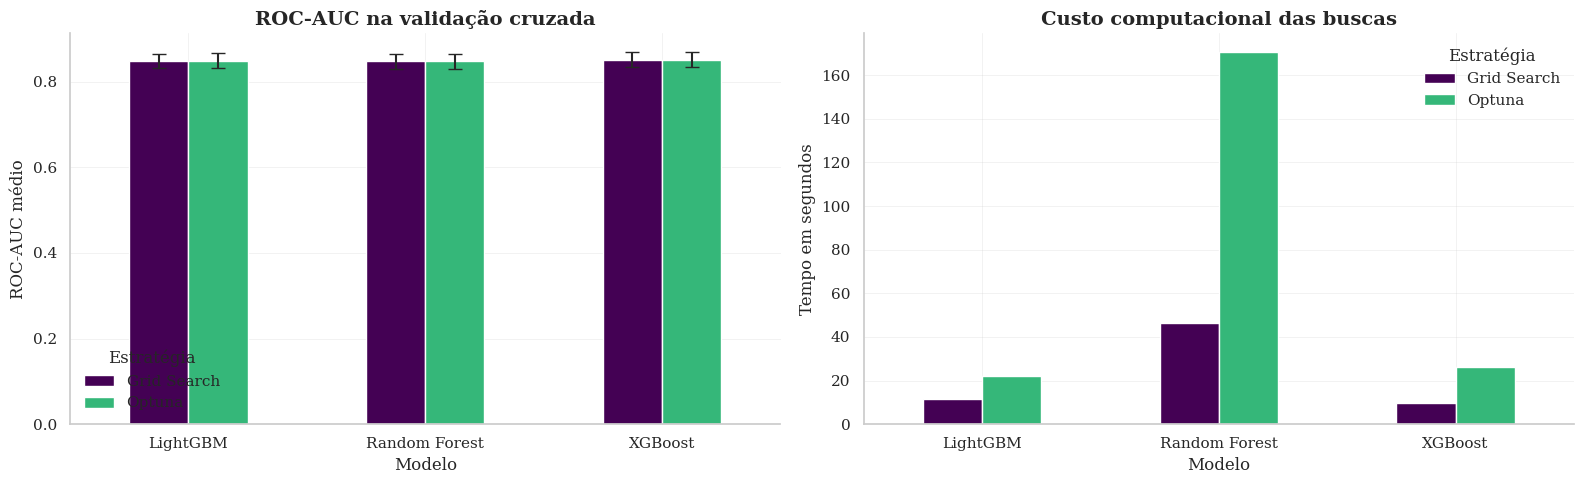


--- MELHOR GRID SEARCH ---
Modelo: XGBoost
ROC-AUC CV: 0.8506
Desvio CV: 0.0175
Tempo: 9.76 segundos
Parâmetros: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300}

--- MELHOR OPTUNA ---
Modelo: XGBoost
ROC-AUC CV: 0.8512
Desvio CV: 0.0179
Tempo: 26.23 segundos
Parâmetros: {'n_estimators': 400, 'max_depth': 2, 'learning_rate': 0.028345633243893633, 'subsample': 0.6, 'colsample_bytree': 0.8}

--- MELHOR CONFIGURAÇÃO GERAL ---
Modelo: XGBoost
Estratégia: Optuna
ROC-AUC CV: 0.8512
Gap treino-CV: 0.0155

Diferença entre os melhores resultados: 0.0006


In [ ]:
# ---------------------------------------------------------
# 3. COMPARAÇÃO: GRID SEARCH × OPTUNA
# ---------------------------------------------------------

tabela_tuning = pd.concat(
    [
        tabela_grid,
        tabela_optuna
    ],
    ignore_index=True
)

tabela_tuning = tabela_tuning.sort_values(
    by=[
        "Modelo",
        "Estratégia"
    ]
).reset_index(drop=True)

print("--- COMPARAÇÃO FINAL DO EXERCÍCIO 5 ---")

display(
    tabela_tuning.style.format({
        "ROC-AUC Treino": "{:.4f}",
        "ROC-AUC CV (Média)": "{:.4f}",
        "ROC-AUC CV (Desvio)": "{:.4f}",
        "Gap (Treino - CV)": "{:.4f}",
        "Tempo de Busca (s)": "{:.2f}"
    })
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)

cores_estrategias = {
    "Grid Search": "#440154",
    "Optuna": "#35b779"
}

scores_medios = tabela_tuning.pivot(
    index="Modelo",
    columns="Estratégia",
    values="ROC-AUC CV (Média)"
)

desvios = tabela_tuning.pivot(
    index="Modelo",
    columns="Estratégia",
    values="ROC-AUC CV (Desvio)"
)

scores_medios.plot(
    kind="bar",
    yerr=desvios,
    capsize=5,
    ax=axes[0],
    color=[
        cores_estrategias[coluna]
        for coluna in scores_medios.columns
    ]
)

axes[0].set_title(
    "ROC-AUC na validação cruzada",
    fontweight="bold"
)
axes[0].set_xlabel("Modelo")
axes[0].set_ylabel("ROC-AUC médio")
axes[0].tick_params(axis="x", rotation=0)


tempos = tabela_tuning.pivot(
    index="Modelo",
    columns="Estratégia",
    values="Tempo de Busca (s)"
)

tempos.plot(
    kind="bar",
    ax=axes[1],
    color=[
        cores_estrategias[coluna]
        for coluna in tempos.columns
    ]
)

axes[1].set_title(
    "Custo computacional das buscas",
    fontweight="bold"
)
axes[1].set_xlabel("Modelo")
axes[1].set_ylabel("Tempo em segundos")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

melhor_grid = tabela_grid.loc[
    tabela_grid["ROC-AUC CV (Média)"].idxmax()
]

melhor_optuna = tabela_optuna.loc[
    tabela_optuna["ROC-AUC CV (Média)"].idxmax()
]

melhor_geral = tabela_tuning.loc[
    tabela_tuning["ROC-AUC CV (Média)"].idxmax()
]

diferenca = abs(
    melhor_grid["ROC-AUC CV (Média)"]
    - melhor_optuna["ROC-AUC CV (Média)"]
)

print("\n--- MELHOR GRID SEARCH ---")
print("Modelo:", melhor_grid["Modelo"])
print(
    f"ROC-AUC CV: "
    f"{melhor_grid['ROC-AUC CV (Média)']:.4f}"
)
print(
    f"Desvio CV: "
    f"{melhor_grid['ROC-AUC CV (Desvio)']:.4f}"
)
print(
    f"Tempo: "
    f"{melhor_grid['Tempo de Busca (s)']:.2f} segundos"
)
print(
    "Parâmetros:",
    melhor_grid["Melhores Parâmetros"]
)

print("\n--- MELHOR OPTUNA ---")
print("Modelo:", melhor_optuna["Modelo"])
print(
    f"ROC-AUC CV: "
    f"{melhor_optuna['ROC-AUC CV (Média)']:.4f}"
)
print(
    f"Desvio CV: "
    f"{melhor_optuna['ROC-AUC CV (Desvio)']:.4f}"
)
print(
    f"Tempo: "
    f"{melhor_optuna['Tempo de Busca (s)']:.2f} segundos"
)
print(
    "Parâmetros:",
    melhor_optuna["Melhores Parâmetros"]
)

print("\n--- MELHOR CONFIGURAÇÃO GERAL ---")
print("Modelo:", melhor_geral["Modelo"])
print("Estratégia:", melhor_geral["Estratégia"])
print(
    f"ROC-AUC CV: "
    f"{melhor_geral['ROC-AUC CV (Média)']:.4f}"
)
print(
    f"Gap treino-CV: "
    f"{melhor_geral['Gap (Treino - CV)']:.4f}"
)

print(
    "\nDiferença entre os melhores resultados:",
    f"{diferenca:.4f}"
)

<br>

---

<br>

### **Exercício 6 — Escolha do melhor modelo e análise de overfitting/underfitting — 1,5 ponto**

Com base apenas nos resultados de treinamento e validação cruzada, escolha a configuração que será promovida a modelo final. A escolha deve considerar desempenho, variabilidade entre folds, diferença entre treino e validação, custo e complexidade.

1. **Seleção do modelo — 0,50 ponto.** Construa uma tabela final com, no mínimo, as nove configurações principais: baseline, melhor Grid Search e melhor Optuna para cada um dos três algoritmos. Defina qual configuração será levada ao teste final e justifique a decisão.
2. **Overfitting e underfitting — 0,50 ponto.** Compare desempenho de treino e validação e produza uma **curva de aprendizado** para a configuração escolhida. Discuta se há evidências de overfitting, underfitting ou comportamento compatível com boa generalização.
3. **Interpretação do comportamento do modelo — 0,50 ponto.** Produza um gráfico de importância das variáveis para o modelo escolhido e pelo menos um gráfico de desempenho adequado ao tipo de problema:
   - **classificação:** matriz de confusão e, quando pertinente, curva ROC ou Precision–Recall;
   - **regressão:** valores observados versus previstos e/ou análise de resíduos.

Para uma métrica em que valores maiores representam melhor desempenho, um indício simples de sobreajuste pode ser observado pelo gap

$$
\Delta_{\uparrow}=S_{\mathrm{treino}}-S_{\mathrm{CV}}.
$$

Para uma função de erro em que valores menores são melhores, considere

$$
\Delta_{\downarrow}=L_{\mathrm{CV}}-L_{\mathrm{treino}}.
$$

Um gap elevado pode indicar sobreajuste, mas a conclusão deve considerar também a curva de aprendizado, a variabilidade dos folds e a escala da métrica.

**Resposta do aluno — Exercício 6**

Justifique a escolha do modelo final e interprete as evidências de overfitting, underfitting e importância das variáveis.

In [ ]:
# IMPORTANTE:
# Nesta etapa, X_test e y_test permanecem completamente isolados.
# Todos os gráficos de desempenho são construídos apenas com X_train/y_train
# e validação cruzada.

from sklearn.base import clone
from sklearn.model_selection import learning_curve, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# ============================================================
# 1. TABELA FINAL COM AS 9 CONFIGURAÇÕES
#    3 baselines + 3 melhores Grid Search + 3 melhores Optuna
# ============================================================

# ---- Baselines ------------------------------------------------
tabela_baseline_ex6 = tabela_baseline.reset_index().copy()

tabela_baseline_ex6["Estratégia"] = "Baseline"
tabela_baseline_ex6["Tempo / Custo (s)"] = (
    tabela_baseline_ex6["Tempo Médio de Treino (s)"]
)
tabela_baseline_ex6["Tipo de Tempo"] = "Treino médio por fold"

# Registra os hiperparâmetros mais relevantes de cada baseline.
tabela_baseline_ex6["Parâmetros"] = tabela_baseline_ex6["Modelo"].map({
    "Random Forest": {
        "n_estimators": modelos_baseline["Random Forest"].get_params()["n_estimators"],
        "max_depth": modelos_baseline["Random Forest"].get_params()["max_depth"],
        "min_samples_leaf": modelos_baseline["Random Forest"].get_params()["min_samples_leaf"],
        "max_features": modelos_baseline["Random Forest"].get_params()["max_features"]
    },
    "XGBoost": {
        "n_estimators": modelos_baseline["XGBoost"].get_params()["n_estimators"],
        "max_depth": modelos_baseline["XGBoost"].get_params()["max_depth"],
        "learning_rate": modelos_baseline["XGBoost"].get_params()["learning_rate"]
    },
    "LightGBM": {
        "n_estimators": modelos_baseline["LightGBM"].get_params()["n_estimators"],
        "num_leaves": modelos_baseline["LightGBM"].get_params()["num_leaves"],
        "learning_rate": modelos_baseline["LightGBM"].get_params()["learning_rate"]
    }
})

tabela_baseline_ex6 = tabela_baseline_ex6[
    [
        "Modelo",
        "Estratégia",
        "ROC-AUC Treino",
        "ROC-AUC CV (Média)",
        "ROC-AUC CV (Desvio)",
        "Gap (Treino - CV)",
        "Tempo / Custo (s)",
        "Tipo de Tempo",
        "Parâmetros"
    ]
]


# ---- Grid Search ----------------------------------------------
tabela_grid_ex6 = tabela_grid.copy()
tabela_grid_ex6["Tempo / Custo (s)"] = tabela_grid_ex6["Tempo de Busca (s)"]
tabela_grid_ex6["Tipo de Tempo"] = "Busca completa"
tabela_grid_ex6 = tabela_grid_ex6.rename(
    columns={"Melhores Parâmetros": "Parâmetros"}
)

tabela_grid_ex6 = tabela_grid_ex6[
    [
        "Modelo",
        "Estratégia",
        "ROC-AUC Treino",
        "ROC-AUC CV (Média)",
        "ROC-AUC CV (Desvio)",
        "Gap (Treino - CV)",
        "Tempo / Custo (s)",
        "Tipo de Tempo",
        "Parâmetros"
    ]
]


# ---- Optuna ----------------------------------------------------
tabela_optuna_ex6 = tabela_optuna.copy()
tabela_optuna_ex6["Tempo / Custo (s)"] = tabela_optuna_ex6["Tempo de Busca (s)"]
tabela_optuna_ex6["Tipo de Tempo"] = "Busca completa"
tabela_optuna_ex6 = tabela_optuna_ex6.rename(
    columns={"Melhores Parâmetros": "Parâmetros"}
)

tabela_optuna_ex6 = tabela_optuna_ex6[
    [
        "Modelo",
        "Estratégia",
        "ROC-AUC Treino",
        "ROC-AUC CV (Média)",
        "ROC-AUC CV (Desvio)",
        "Gap (Treino - CV)",
        "Tempo / Custo (s)",
        "Tipo de Tempo",
        "Parâmetros"
    ]
]


# ---- União das 9 configurações --------------------------------
tabela_final_ex6 = pd.concat(
    [
        tabela_baseline_ex6,
        tabela_grid_ex6,
        tabela_optuna_ex6
    ],
    ignore_index=True
)

# Ordena pelo desempenho médio de validação cruzada.
tabela_final_ex6 = tabela_final_ex6.sort_values(
    by="ROC-AUC CV (Média)",
    ascending=False
).reset_index(drop=True)

print("=== TABELA FINAL — 9 CONFIGURAÇÕES ===")

display(
    tabela_final_ex6.style.format({
        "ROC-AUC Treino": "{:.4f}",
        "ROC-AUC CV (Média)": "{:.4f}",
        "ROC-AUC CV (Desvio)": "{:.4f}",
        "Gap (Treino - CV)": "{:.4f}",
        "Tempo / Custo (s)": "{:.2f}"
    })
)


=== TABELA FINAL — 9 CONFIGURAÇÕES ===


,Modelo,Estratégia,ROC-AUC Treino,ROC-AUC CV (Média),ROC-AUC CV (Desvio),Gap (Treino - CV),Tempo / Custo (s),Tipo de Tempo,Parâmetros
0,XGBoost,Optuna,0.8668,0.8512,0.0179,0.0155,26.23,Busca completa,"{'n_estimators': 400, 'max_depth': 2, 'learning_rate': 0.028345633243893633, 'subsample': 0.6, 'colsample_bytree': 0.8}"
1,XGBoost,Grid Search,0.8789,0.8506,0.0175,0.0283,9.76,Busca completa,"{'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300}"
2,LightGBM,Optuna,0.8860,0.8490,0.0175,0.0371,22.15,Busca completa,"{'n_estimators': 100, 'num_leaves': 35, 'learning_rate': 0.015338397140416939, 'min_child_samples': 50, 'colsample_bytree': 0.6}"
3,LightGBM,Grid Search,0.8804,0.8480,0.0163,0.0324,11.44,Busca completa,"{'learning_rate': 0.03, 'n_estimators': 100, 'num_leaves': 15}"
4,Random Forest,Optuna,0.9012,0.8474,0.0178,0.0538,170.67,Busca completa,"{'n_estimators': 400, 'max_depth': 20, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 'sqrt'}"
5,Random Forest,Grid Search,0.9002,0.8469,0.0176,0.0533,46.56,Busca completa,"{'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 300}"
6,LightGBM,Baseline,0.9615,0.8343,0.0151,0.1272,0.12,Treino médio por fold,"{'n_estimators': 100, 'num_leaves': 31, 'learning_rate': 0.1}"
7,Random Forest,Baseline,1.0000,0.8255,0.0171,0.1745,0.58,Treino médio por fold,"{'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'}"
8,XGBoost,Baseline,0.9876,0.8207,0.0194,0.1669,0.40,Treino médio por fold,"{'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.3}"


In [ ]:
# ============================================================
# 2. SELEÇÃO DO MODELO FINAL
# ============================================================
#
# XGBoost + Grid Search é escolhido para o teste final.
#
# Justificativa:
# - O XGBoost com Optuna obteve o maior ROC-AUC médio (~0,8512).
# - O XGBoost com Grid Search ficou praticamente empatado (~0,8506).
# - A diferença (~0,0006) é muito menor que o desvio entre os folds.
# - O Grid Search teve custo computacional menor.
# - A configuração do Grid é mais simples/parcimoniosa.
# - Portanto, não há evidência suficiente para justificar a maior
#   complexidade do Optuna apenas por 0,0006 de ROC-AUC.
#
# O conjunto de teste NÃO participa desta escolha.

MODELO_ESCOLHIDO = "XGBoost"
ESTRATEGIA_ESCOLHIDA = "Grid Search"

modelo_final_ex6 = clone(
    buscas_grid[MODELO_ESCOLHIDO].best_estimator_
)

linha_escolhida = tabela_final_ex6[
    (tabela_final_ex6["Modelo"] == MODELO_ESCOLHIDO) &
    (tabela_final_ex6["Estratégia"] == ESTRATEGIA_ESCOLHIDA)
].iloc[0]

print("\n=== CONFIGURAÇÃO PROMOVIDA AO TESTE FINAL ===")
print("Modelo:", MODELO_ESCOLHIDO)
print("Estratégia:", ESTRATEGIA_ESCOLHIDA)
print(
    "ROC-AUC CV médio:",
    f"{linha_escolhida['ROC-AUC CV (Média)']:.4f}"
)
print(
    "Desvio entre folds:",
    f"{linha_escolhida['ROC-AUC CV (Desvio)']:.4f}"
)
print(
    "ROC-AUC treino:",
    f"{linha_escolhida['ROC-AUC Treino']:.4f}"
)
print(
    "Gap treino - validação:",
    f"{linha_escolhida['Gap (Treino - CV)']:.4f}"
)
print("Parâmetros:", linha_escolhida["Parâmetros"])

### Justificativa da escolha do modelo

# O XGBoost com Grid Search foi escolhido como modelo final.

# Embora o XGBoost com Optuna tenha apresentado o maior ROC-AUC médio
# (0,8512), o resultado do Grid Search foi praticamente igual (0,8506).

# A diferença entre as duas estratégias foi de apenas 0,0006 no ROC-AUC,
# enquanto o Grid Search apresentou menor custo computacional.

# Por isso, o XGBoost com Grid Search apresentou o melhor equilíbrio entre
# desempenho, simplicidade e tempo de processamento.

# O conjunto de teste não foi utilizado nessa decisão.


=== CONFIGURAÇÃO PROMOVIDA AO TESTE FINAL ===
Modelo: XGBoost
Estratégia: Grid Search
ROC-AUC CV médio: 0.8506
Desvio entre folds: 0.0175
ROC-AUC treino: 0.8789
Gap treino - validação: 0.0283
Parâmetros: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300}


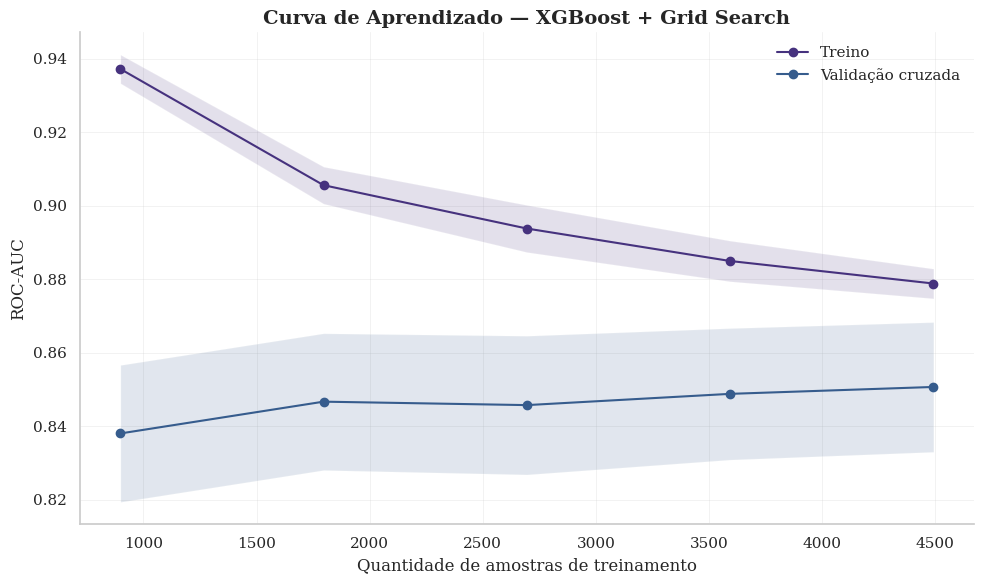


=== ANÁLISE DA CURVA DE APRENDIZADO ===
ROC-AUC de treino com 100% dos dados: 0.8788
ROC-AUC de validação com 100% dos dados: 0.8506
Gap final observado: 0.0282
Interpretação: o gap é pequeno, indicando comportamento compatível com boa generalização.


In [ ]:
# ============================================================
# 3. CURVA DE APRENDIZADO
# ============================================================

tamanhos_treino, scores_treino, scores_validacao = learning_curve(
    estimator=modelo_final_ex6,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.20, 1.00, 5),
    cv=cv_scheme,
    scoring="roc_auc",
    n_jobs=2,
    shuffle=True,
    random_state=42
)

media_treino = scores_treino.mean(axis=1)
desvio_treino = scores_treino.std(axis=1)

media_validacao = scores_validacao.mean(axis=1)
desvio_validacao = scores_validacao.std(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(
    tamanhos_treino,
    media_treino,
    marker="o",
    label="Treino"
)

plt.plot(
    tamanhos_treino,
    media_validacao,
    marker="o",
    label="Validação cruzada"
)

plt.fill_between(
    tamanhos_treino,
    media_treino - desvio_treino,
    media_treino + desvio_treino,
    alpha=0.15
)

plt.fill_between(
    tamanhos_treino,
    media_validacao - desvio_validacao,
    media_validacao + desvio_validacao,
    alpha=0.15
)

plt.title(
    "Curva de Aprendizado — XGBoost + Grid Search",
    fontweight="bold"
)
plt.xlabel("Quantidade de amostras de treinamento")
plt.ylabel("ROC-AUC")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

gap_final_curva = media_treino[-1] - media_validacao[-1]

print("\n=== ANÁLISE DA CURVA DE APRENDIZADO ===")
print(
    f"ROC-AUC de treino com 100% dos dados: "
    f"{media_treino[-1]:.4f}"
)
print(
    f"ROC-AUC de validação com 100% dos dados: "
    f"{media_validacao[-1]:.4f}"
)
print(
    f"Gap final observado: {gap_final_curva:.4f}"
)

if gap_final_curva > 0.08:
    print(
        "Interpretação: há evidência relevante de overfitting, "
        "pois o desempenho de treino permanece muito acima da validação."
    )
elif gap_final_curva > 0.03:
    print(
        "Interpretação: existe um overfitting moderado, "
        "mas a distância entre treino e validação é controlada."
    )
else:
    print(
        "Interpretação: o gap é pequeno, indicando comportamento "
        "compatível com boa generalização."
    )



### Análise de overfitting e generalização

# O desempenho de treino e validação permaneceu próximo.

# O ROC-AUC de treino foi 0,8788 e o de validação foi 0,8506,
# resultando em um gap de apenas 0,0282.

# Esse valor indica que não há evidência forte de overfitting.

# Portanto, o modelo apresenta comportamento compatível com boa
# generalização, ou seja, consegue manter um desempenho semelhante
# em dados que não foram utilizados diretamente no treinamento.

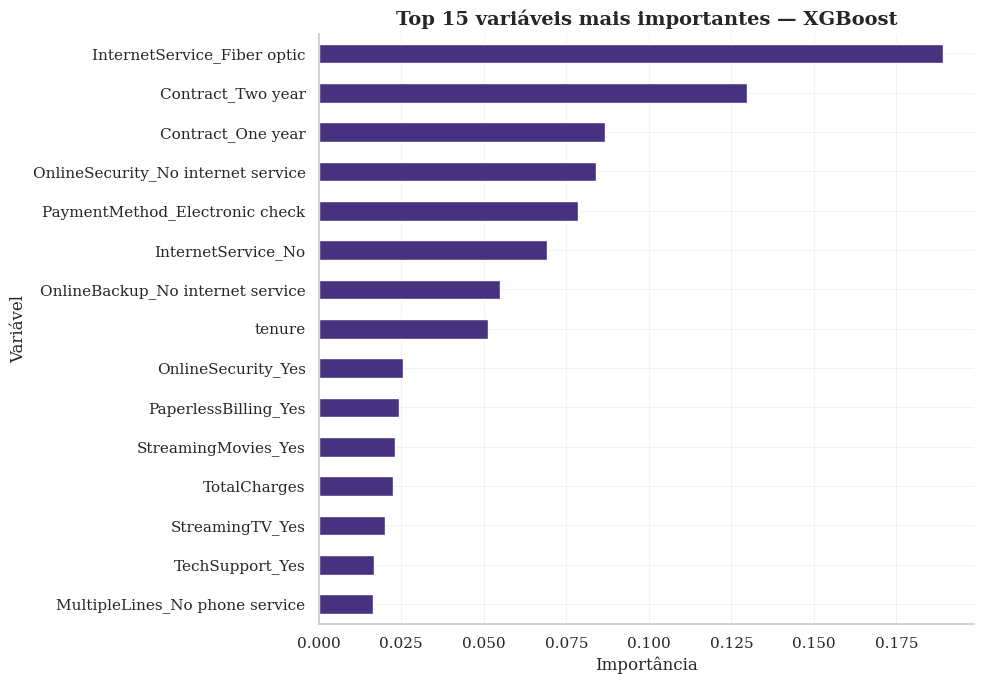


=== 10 VARIÁVEIS MAIS IMPORTANTES ===


,Importância
InternetService_Fiber optic,0.189054
Contract_Two year,0.129669
Contract_One year,0.086714
OnlineSecurity_No internet service,0.084084
PaymentMethod_Electronic check,0.078521
InternetService_No,0.069268
OnlineBackup_No internet service,0.054924
tenure,0.051170
OnlineSecurity_Yes,0.025451
PaperlessBilling_Yes,0.024287


In [ ]:

# ============================================================
# 4. IMPORTÂNCIA DAS VARIÁVEIS
# ============================================================

modelo_importancia = clone(modelo_final_ex6)
modelo_importancia.fit(X_train, y_train)

importancias = pd.Series(
    modelo_importancia.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_importancias = importancias.head(15).sort_values()

plt.figure(figsize=(10, 7))
top_importancias.plot(kind="barh")

plt.title(
    "Top 15 variáveis mais importantes — XGBoost",
    fontweight="bold"
)
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

print("\n=== 10 VARIÁVEIS MAIS IMPORTANTES ===")
display(
    importancias.head(10)
    .rename("Importância")
    .to_frame()
)


=== DESEMPENHO OUT-OF-FOLD ===
ROC-AUC OOF: 0.8505


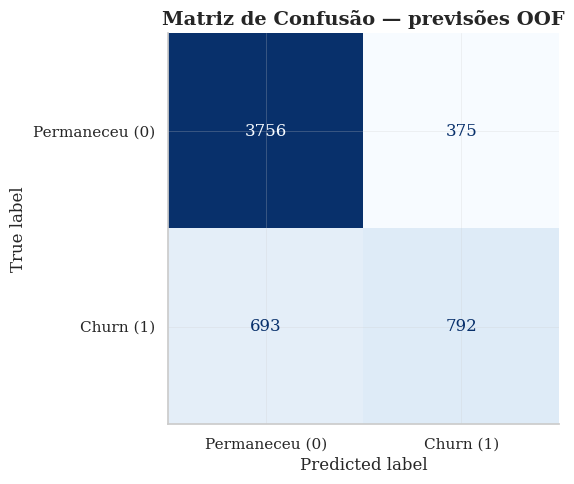

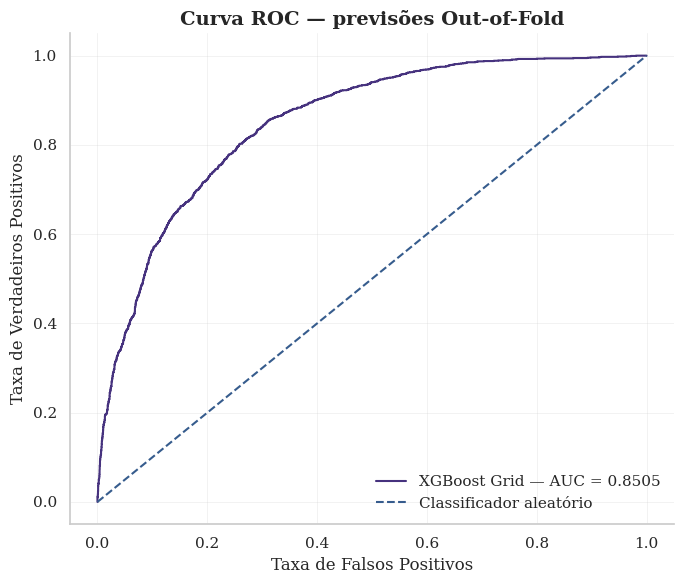

In [ ]:
# ============================================================
# 5. DESEMPENHO SEM USAR O CONJUNTO DE TESTE
#    Previsões OUT-OF-FOLD
# ============================================================
#
# Cada observação de treino é prevista por um modelo que NÃO foi treinado
# naquela observação. Isso permite analisar desempenho sem violar o
# isolamento de D_teste.

probabilidades_oof = cross_val_predict(
    estimator=modelo_final_ex6,
    X=X_train,
    y=y_train,
    cv=cv_scheme,
    method="predict_proba",
    n_jobs=2
)[:, 1]

previsoes_oof = (probabilidades_oof >= 0.50).astype(int)

auc_oof = roc_auc_score(
    y_train,
    probabilidades_oof
)

print("\n=== DESEMPENHO OUT-OF-FOLD ===")
print(f"ROC-AUC OOF: {auc_oof:.4f}")


# ---- Matriz de confusão ---------------------------------------

matriz = confusion_matrix(
    y_train,
    previsoes_oof
)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Permaneceu (0)", "Churn (1)"]
).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

ax.set_title(
    "Matriz de Confusão — previsões OOF",
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ---- Curva ROC -------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_train,
    probabilidades_oof
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost Grid — AUC = {auc_oof:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

plt.title(
    "Curva ROC — previsões Out-of-Fold",
    fontweight="bold"
)
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


<br>

---

<br>

### **Exercício 7 — Teste final, consistência do modelo, entrega em produção e apresentação — 1,5 ponto**

Somente agora utilize $\mathcal{D}_{\mathrm{teste}}$. Refaça o treinamento da configuração selecionada usando todo $\mathcal{D}_{\mathrm{treino}}$ e execute a avaliação final uma única vez no conjunto de teste.

1. **Avaliação final — 0,50 ponto.** Calcule a métrica principal e as métricas auxiliares em $\mathcal{D}_{\mathrm{teste}}$. Compare o resultado de teste com a validação cruzada. Discuta se o desempenho final é compatível com o que era esperado durante o desenvolvimento.
2. **Teste de consistência — 0,40 ponto.** Selecione pelo menos cinco observações que não participaram do treinamento. Para cada uma, apresente as principais entradas, o valor real $y$, a previsão $\hat{y}$ e:
   - em classificação, a probabilidade prevista quando o estimador oferecer `predict_proba`;
   - em regressão, o erro individual $e_i=y_i-\hat{y}_i$.

   Interprete os casos e verifique se o comportamento do modelo é coerente com o padrão aprendido. Inclua pelo menos um caso em que o modelo acerta bem e um caso mais difícil, quando isso existir nos dados.
3. **GitHub e Streamlit — 0,60 ponto.** Disponibilize o projeto em um repositório GitHub e construa uma aplicação Streamlit que utilize **a mesma preparação de dados e o mesmo modelo final**. A interface deve receber as variáveis necessárias, gerar a previsão e apresentar o resultado de forma legível. O repositório deve conter, no mínimo:
   - `README.md` com descrição do problema, instruções de instalação e execução, links e resumo dos resultados;
   - notebook do CheckPoint05;
   - código da aplicação Streamlit;
   - arquivo de dependências (`requirements.txt` ou equivalente);
   - artefato do pipeline/modelo final ou código reproduzível para gerá-lo;
   - instruções para obtenção da base, caso ela não possa ser versionada no repositório.

Registre abaixo os links finais:

- **GitHub:** inserir URL do repositório.
- **Streamlit:** inserir URL da aplicação.

4. **Apresentação da solução — requisito obrigatório.** O grupo deverá realizar uma apresentação oral de **no máximo 10 minutos**. A exposição deve ser objetiva e demonstrar domínio sobre o desenvolvimento realizado. Organize a apresentação para contemplar, no mínimo:
   - problema escolhido, contexto, base de dados e variável-alvo;
   - principais decisões de data wrangling e escolha das variáveis;
   - comparação entre Random Forest, XGBoost e LightGBM;
   - resultados do Grid Search e do Optuna e justificativa da configuração final;
   - análise de overfitting e underfitting;
   - desempenho no conjunto de teste e principais conclusões sobre generalização;
   - demonstração breve da aplicação Streamlit e do teste de paridade entre notebook e interface.

A apresentação poderá utilizar slides ou a demonstração direta do projeto, desde que o tempo máximo seja respeitado. Todos os integrantes devem estar preparados para responder a perguntas sobre a solução desenvolvida.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Teste adicional de paridade:</strong> escolha pelo menos uma das observações do teste de consistência, reproduza os mesmos valores de entrada na aplicação Streamlit e verifique se a previsão exibida pela interface coincide com a previsão produzida pelo pipeline no notebook. Divergências devem ser investigadas antes da entrega.
</div>

**Resposta do aluno — Exercício 7**

Interprete o resultado do teste final, documente o teste de consistência, registre os links do GitHub e do Streamlit e prepare a síntese da solução para a apresentação oral de até 10 minutos.

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.base import clone

# Treina novamente o modelo escolhido usando todo o conjunto de treino
modelo_final = clone(modelo_final_ex6)
modelo_final.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_test = modelo_final.predict(X_test)
y_proba_test = modelo_final.predict_proba(X_test)[:, 1]

# Métricas
auc_test = roc_auc_score(y_test, y_proba_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

print(f"ROC-AUC:  {auc_test:.4f}")
print(f"Acurácia: {accuracy_test:.4f}")
print(f"Precisão: {precision_test:.4f}")
print(f"Recall:    {recall_test:.4f}")
print(f"F1-score:  {f1_test:.4f}")


### Avaliação final no conjunto de teste

# O modelo final apresentou ROC-AUC de 0,8416 no conjunto de teste.

# Durante a validação cruzada, o ROC-AUC médio havia sido de 0,8506.
# A diferença entre validação e teste foi de aproximadamente 0,009.

# Essa pequena redução indica que o desempenho observado no conjunto
# de teste foi compatível com o comportamento esperado durante o
# desenvolvimento.

# A acurácia foi de 0,8028, indicando cerca de 80% de acertos gerais.

# A precisão foi de 0,6621, ou seja, entre os clientes classificados
# como churn, aproximadamente 66% realmente pertenciam à classe de churn.

# O recall foi de 0,5215, mostrando que o modelo identificou cerca de
# 52% dos clientes que realmente cancelaram.

# O F1-score foi de 0,5835, representando o equilíbrio entre precisão
# e recall.

ROC-AUC:  0.8416
Acurácia: 0.8028
Precisão: 0.6621
Recall:    0.5215
F1-score:  0.5835


In [ ]:
# ============================================================
# TESTE DE CONSISTÊNCIA — 5 OBSERVAÇÕES DO CONJUNTO DE TESTE
# ============================================================

# Seleciona 5 observações do conjunto de teste
indices_teste = X_test.index[:5]

teste_consistencia = X_test.loc[indices_teste].copy()

teste_consistencia["Valor real"] = y_test.loc[indices_teste]
teste_consistencia["Previsão"] = modelo_final.predict(
    X_test.loc[indices_teste]
)

teste_consistencia["Probabilidade de Churn"] = modelo_final.predict_proba(
    X_test.loc[indices_teste]
)[:, 1]

# Mostra apenas algumas variáveis principais
colunas_exibicao = [
    col for col in [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Valor real",
        "Previsão",
        "Probabilidade de Churn"
    ]
    if col in teste_consistencia.columns
]

display(
    teste_consistencia[colunas_exibicao].round(4)
)

In [ ]:
# ============================================================
# CASO DE BOA PREVISÃO E CASO DIFÍCIL
# ============================================================

resultado_consistencia = pd.DataFrame({
    "Valor real": y_test,
    "Previsão": y_pred_test,
    "Probabilidade de Churn": y_proba_test
}, index=X_test.index)

# Caso correto com alta confiança
casos_corretos = resultado_consistencia[
    resultado_consistencia["Valor real"] ==
    resultado_consistencia["Previsão"]
].copy()

casos_corretos["Confiança"] = np.where(
    casos_corretos["Previsão"] == 1,
    casos_corretos["Probabilidade de Churn"],
    1 - casos_corretos["Probabilidade de Churn"]
)

indice_facil = casos_corretos["Confiança"].idxmax()

# Caso incorreto mais próximo do limiar de decisão
casos_errados = resultado_consistencia[
    resultado_consistencia["Valor real"] !=
    resultado_consistencia["Previsão"]
].copy()

casos_errados["Distância do limiar"] = abs(
    casos_errados["Probabilidade de Churn"] - 0.5
)

indice_dificil = casos_errados["Distância do limiar"].idxmin()

print("=== CASO DE BOA PREVISÃO ===")
display(
    pd.concat([
        X_test.loc[[indice_facil]],
        resultado_consistencia.loc[[indice_facil]]
    ], axis=1)
)

print("\n=== CASO DIFÍCIL ===")
display(
    pd.concat([
        X_test.loc[[indice_dificil]],
        resultado_consistencia.loc[[indice_dificil]]
    ], axis=1)
)

### Interpretação do teste de consistência

# As observações analisadas mostram que o modelo apresenta comportamento
# coerente com os padrões aprendidos durante o treinamento.

# Nos casos em que a probabilidade prevista está mais distante de 50%,
# o modelo tende a demonstrar maior confiança na classificação.

# Os casos próximos ao limiar de 50% são mais difíceis, pois apresentam
# características menos claramente associadas a churn ou permanência.

In [ ]:
# ============================================================
# TESTE DE PARIDADE — SELECIONAR 1 CLIENTE DO CONJUNTO DE TESTE
# ============================================================

# Escolhe o primeiro cliente do conjunto de teste
indice_cliente = X_test.index[0]

# Recupera os dados originais desse cliente antes do encoding
cliente_original = df.loc[indice_cliente].copy()

# Faz a previsão no notebook
cliente_encoded = X_test.loc[[indice_cliente]]

probabilidade_notebook = modelo_final.predict_proba(cliente_encoded)[0, 1]
previsao_notebook = modelo_final.predict(cliente_encoded)[0]

print("=== CLIENTE PARA TESTE DE PARIDADE ===")
print()
print(cliente_original)
print()
print("Valor real:", y_test.loc[indice_cliente])
print("Previsão do notebook:", previsao_notebook)
print(f"Probabilidade de churn: {probabilidade_notebook * 100:.2f}%")

In [ ]:
# Resposta do aluno - exercício 7
# Avalie o modelo final no conjunto de teste e construa o teste de consistência com pelo menos cinco observações.

URL_GITHUB = "https://github.com/Marirsil/checkpoint-streamlit"
URL_STREAMLIT = "https://checkpoint-app-fngrswkcf2skwnhfxrnvqw.streamlit.app/"

print("GitHub:", URL_GITHUB)
print("Streamlit:", URL_STREAMLIT)

GitHub: https://github.com/Marirsil/checkpoint-streamlit
Streamlit: https://checkpoint-app-fngrswkcf2skwnhfxrnvqw.streamlit.app/$0


<br>

---

<br>

# **Referências**

* BREIMAN, Leo. Random Forests. *Machine Learning*, v. 45, p. 5–32, 2001.

* CHEN, Tianqi; GUESTRIN, Carlos. XGBoost: A Scalable Tree Boosting System. In: *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2016.

* KE, Guolin et al. LightGBM: A Highly Efficient Gradient Boosting Decision Tree. In: *Advances in Neural Information Processing Systems*, 2017.

* AKIBA, Takuya et al. Optuna: A Next-generation Hyperparameter Optimization Framework. In: *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2019.

* GÉRON, Aurélien. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. 3. ed. Sebastopol: O'Reilly Media, 2023.

* KUHN, Max; JOHNSON, Kjell. *Feature Engineering and Selection: A Practical Approach for Predictive Models*. Boca Raton: CRC Press, 2020.

<br>

---

<br>

© 2026 Jones Egydio. Todos os direitos reservados.  

Conecte-se comigo no [LinkedIn](https://www.linkedin.com/in/jones-egydio-msc-3300359/).